In [205]:
import pandas as pd
import numpy as np
import math
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
pd.set_option('display.float_format', lambda x: '%e' % x)

Vg = 18
u_0 = 4*math.pi*1e-7 # permeability of free space in H/m
R_SH = 0.05

### Prelab 5
I configured my digital twin for flyback operation by adding a transformer to the system and calculating referred values for all of my components. I calculated Ipk by using referred values to create an equivalent buck-boost model of my converter, namely the following equation (once all values are referred):

$I_{pk} = \frac{2}{\sqrt{\alpha}} * (M+1) * \frac{V}{R}$

R, C, V, and M in my initialization script are the values used in my Ipk buck boost equation, whereas R0, C0, V0, and M0 are the actual values of the load resistance, capacitance, output voltage, and voltage conversion ratio. Below is the PLECS model, updated with the new transformer and new initialization script. The transformer has a 1:1 windings ratio and a 1:a turns ratio, where a is a calculated value also in my initialization script. At the top of the script are the values given in the scenario.

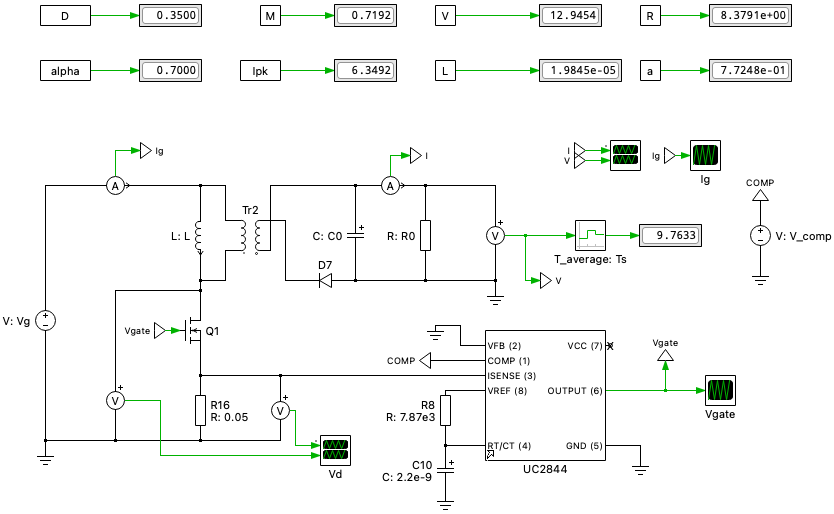

From this we can see that the average output voltage is 9.76V, very close to the desired output voltage of 10V. The calculated Ipk is 6.3492A.

In [206]:
def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

def plot_lab5(filepath, title, x1=None, x2=None, part=1): 
    [data, t0, dT] = read_rigol_csv(filepath)
    fig, ax = plt.subplots(figsize=(10, 6))
    # smooth data
    data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
    data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
    
    if part==1:
        label1="Shunt Voltage (Vsh)"
        label2="Drain Voltage (Vd)"
    else:
        label1="Vinj-"
        label2="Vdd"
    
    data.plot(x="X", y="CH1", ax=ax, label=label1, legend=False, color='tab:blue')
    ax2 = data.plot(x="X", y="CH2", ax=ax, secondary_y=True, label=label2, legend=False, color='tab:orange')


    if part==1:
        fitname="Vsh Linear Fit"
    else:
        fitname="Vout fit"
    subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
    result = linregress(subset['X'], subset['CH1'])
    dVsh_dt = result.slope

    fit = dVsh_dt * subset['X'] + result.intercept
    ax.plot(subset['X'], fit, color="red", linewidth=3, linestyle="dotted", label=fitname)
        
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, 
               loc='upper left', 
               bbox_to_anchor=(1.15, 1.0), 
               borderaxespad=0.)
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel(label1, fontsize=12, color='tab:blue')
    ax2.set_ylabel(label2, fontsize=12, color='tab:orange')
        
    plt.title(title)
    plt.tight_layout()
    plt.show()
    if part==1:
        di_dt = dVsh_dt/R_SH
        L = Vg/di_dt
        print(f"The di/dt value for the linear fit of {title} is {di_dt:.4f}A/s")
        print(f"The measured inductance value for {title} is {L*1e6:.4f}uH")
        vd_subset = data[(data['X'] >= 0.25e-5) & (data['X'] <= 0.5e-5)]
        Avg_Vd = np.mean(vd_subset['CH2'])
        return L, Avg_Vd
    return dVsh_dt

## Lab 5
#### Q1: Take note of the transformer label
Transformer #6
#### Q2: Save shunt and drain voltage measurements as *.csv files to USB stick and plot in Jupyter.

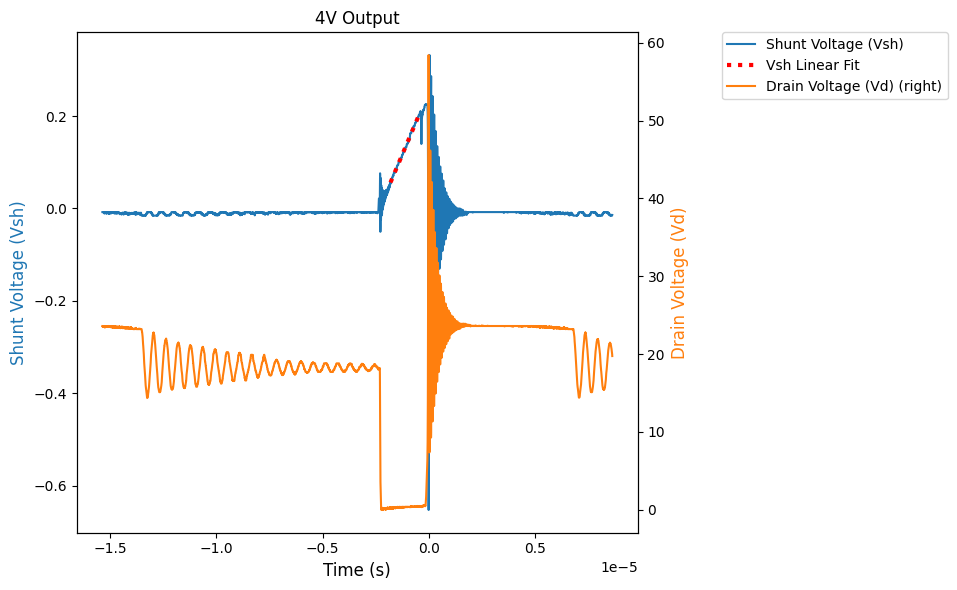

The di/dt value for the linear fit of 4V Output is 2178363.8450A/s
The measured inductance value for 4V Output is 8.2631uH


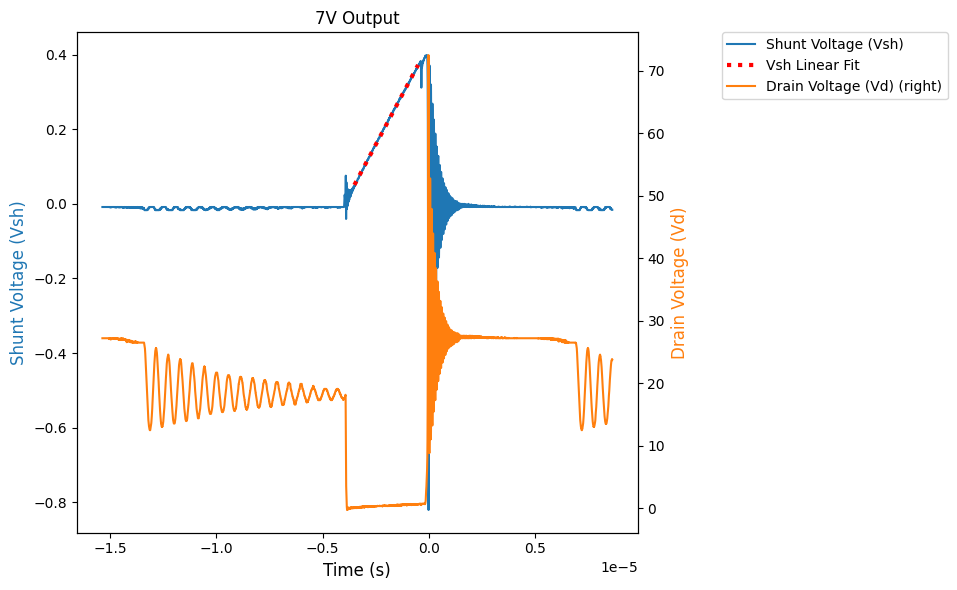

The di/dt value for the linear fit of 7V Output is 2147211.9986A/s
The measured inductance value for 7V Output is 8.3830uH


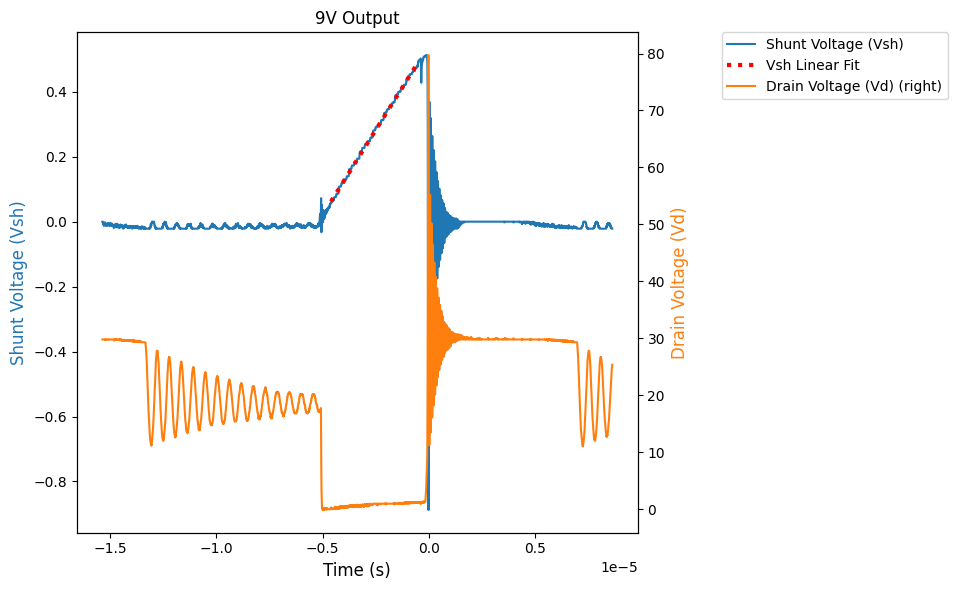

The di/dt value for the linear fit of 9V Output is 2091692.0967A/s
The measured inductance value for 9V Output is 8.6055uH


In [207]:
Lm_4v1, Avg_Vd_4v1 = plot_lab5("data/4vpart1.csv", "4V Output", -1.8e-6, -0.5e-6)
Lm_7v1, Avg_Vd_7v1 = plot_lab5("data/7vpart1.csv", "7V Output", -3.5e-6, -0.5e-6)
Lm_9v1, Avg_Vd_9v1 = plot_lab5("data/9vpart1.csv", "9V Output", -4.6e-6, -0.5e-6)

#### Q3/4: Note the value of the input current supplied by the power supply.
4V: V_out = 4.001V, I_in = 0.30A

7V: V_out = 6.990V, I_in = 0.80A

9V: V_out = 9.000V, I_in = 1.30A

#### Q5/6: Save the voltage measurements as *.csv files to USB stick and plot in Jupyter. Repeat tests at approx. 7V and 9V. Save scope captures for both operating points and plot in Jupyter.

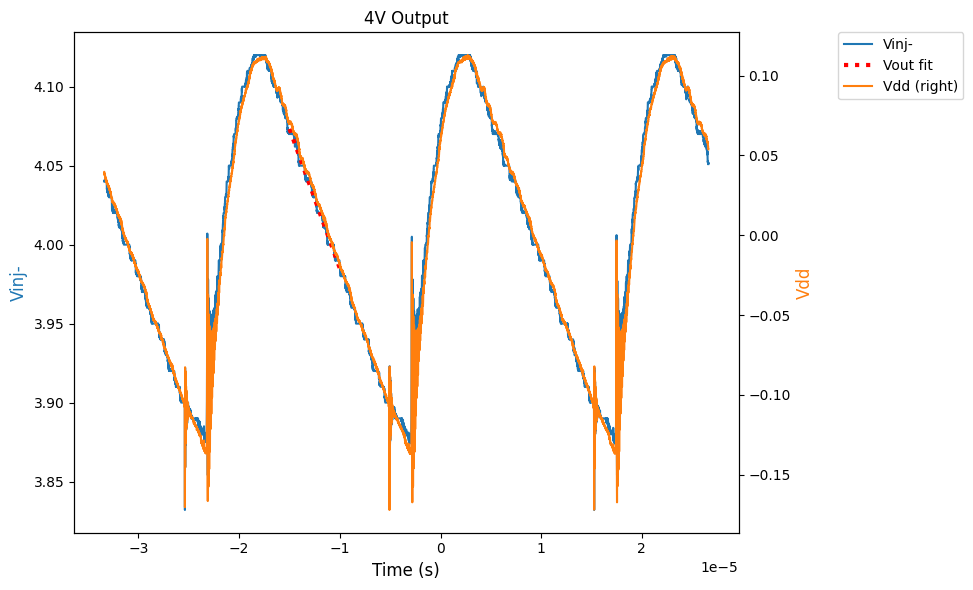

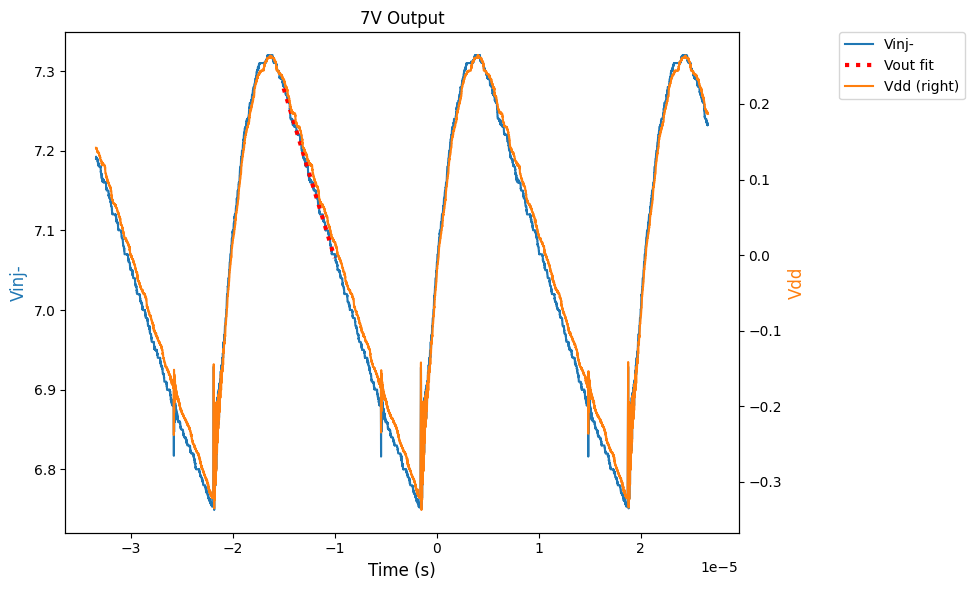

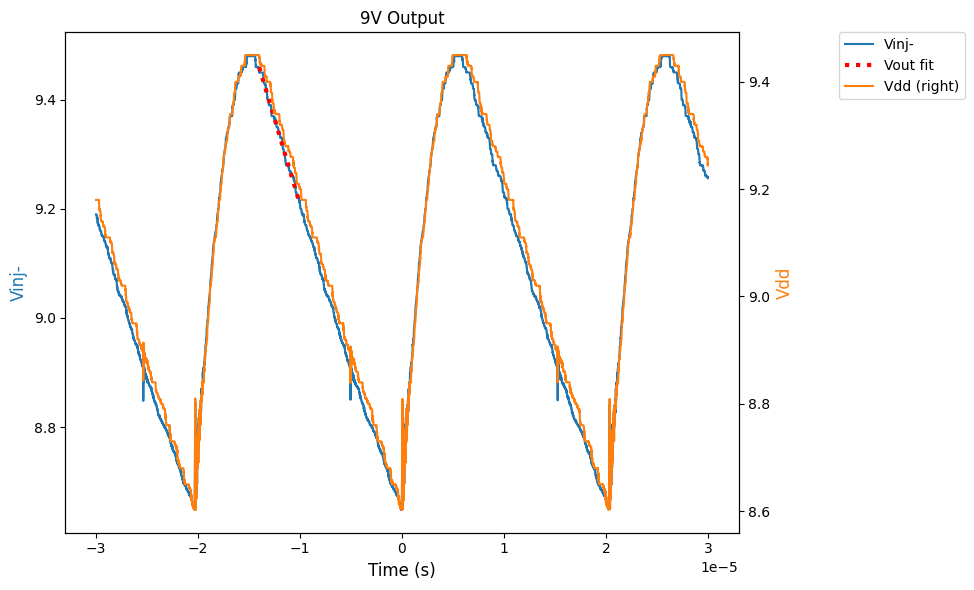

In [208]:
vout_slope4= plot_lab5("data/4vpart2.csv", "4V Output", -1.5e-5, -1e-5, part=2)
vout_slope7=plot_lab5("data/7vpart2.csv", "7V Output", -1.5e-5, -1e-5, part=2)
vout_slope9= plot_lab5("data/9vpart2.csv", "9V Output", -1.4e-5, -1e-5, part=2)

#### Q6: Note actual output voltages.
4V: V_out = 4.003V, I_in = 0.24A

7V: V_out = 7.04V, I_in = 0.81A

9V: V_out = 9.06V, I_in = 1.32A

#### Q7: Use the shunt voltage measurements taken to determine the magnetizing inductance value of the test transformer.\

In [209]:
print(f"\nThe magnetizing inductance, averaged across different output voltage levels, is approximately {np.mean([Lm_4v1, Lm_7v1, Lm_9v1])*1e6:.4f}uH")


The magnetizing inductance, averaged across different output voltage levels, is approximately 8.4172uH


To calculate the magnetizing inductance, we can first relate inductor current to shunt voltage by the following equation: $\frac{dI_m}{dt} = \frac{\frac{dV_{sh}}{dt}}{R_{sh}}$. This is a valid equation because all current flowing through the primary side also flows through the shunt resistor when the switch is closed. From there, we can use $L_m = \frac{V_g}{\frac{dI_m}{dt}}$ and substitute $\frac{dI_m}{dt}$ in. We can extract the value for $\frac{dV_{sh}}{dt}$ from the measurement by taking the slope of Vsh during the period in which the switch is closed, since the inductor current is not passing through the shunt resistor when the switch is open.

I then averaged the three measurements of magnetizing inductance for the three voltage outputs, giving us 8.42uH.

#### Q8: Use the drain voltage measurement to determine the turns ratio "a" of the transformer. Update your PLECS model with the values determined above.

The drain voltage is related to the turns ratio "a" by the equation $V_d = V_g + V_{out}/a$. Solving for "a", we get $a = \frac{V_{out}}{V_d - Vg}$. The drain voltage is extracted by taking the flat value of it when the MOSFET is open and the diode on the secondary side is passing current.

In [210]:
# 4V output (4.001V real output)
a_4v = 4.001/(Avg_Vd_4v1-Vg)
# 7V output (6.990V real output)
a_7v = 6.990/(Avg_Vd_7v1-Vg)
# 9V output (9.000V real output)
a_9v = 9.000/(Avg_Vd_9v1-Vg)

print(f"Average drain voltages (4V, 7V, 9V): {Avg_Vd_4v1:.3f}V, {Avg_Vd_7v1:.3f}V, {Avg_Vd_9v1:.3f}V")
print(f"Turns ratios (4V, 7V, 9V): {a_4v:.4f}, {a_7v:.4f}, {a_9v:.4f}")
print(f"The turns ratio averaged across the different output voltage levels is {np.mean([a_4v, a_7v, a_9v]):.4f}")

Average drain voltages (4V, 7V, 9V): 23.592V, 27.233V, 29.817V
Turns ratios (4V, 7V, 9V): 0.7155, 0.7570, 0.7616
The turns ratio averaged across the different output voltage levels is 0.7447


#### Q9: Run simulations corresponding to the measurements taken and compare the waveforms (shape, amplitude, timing, duty cycle) of the shunt-voltage, drain voltage and output voltage.
I first updated the initialization script to include the measured values we just calculated. I also reordered some equations to make the calculations make chronological sense.

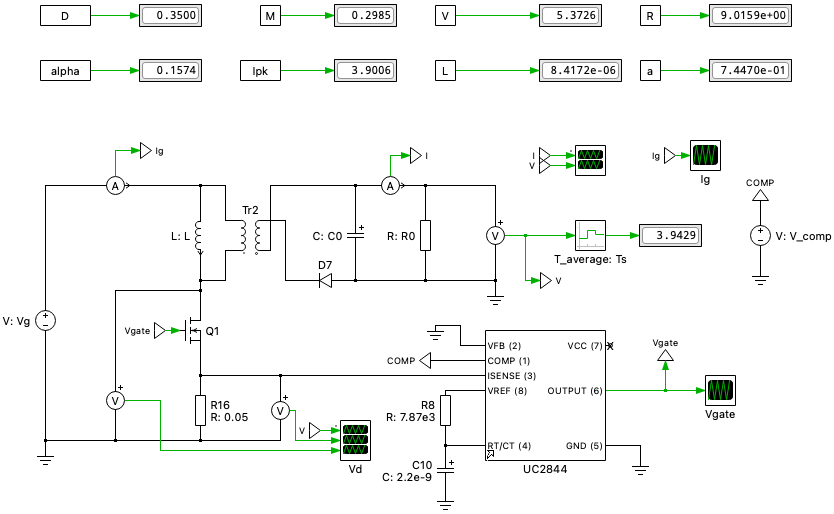

Here we can see the output voltage comes out to 3.943V in simulation, which is very close to the measured value of 4.001V.

#### 4.001V Output
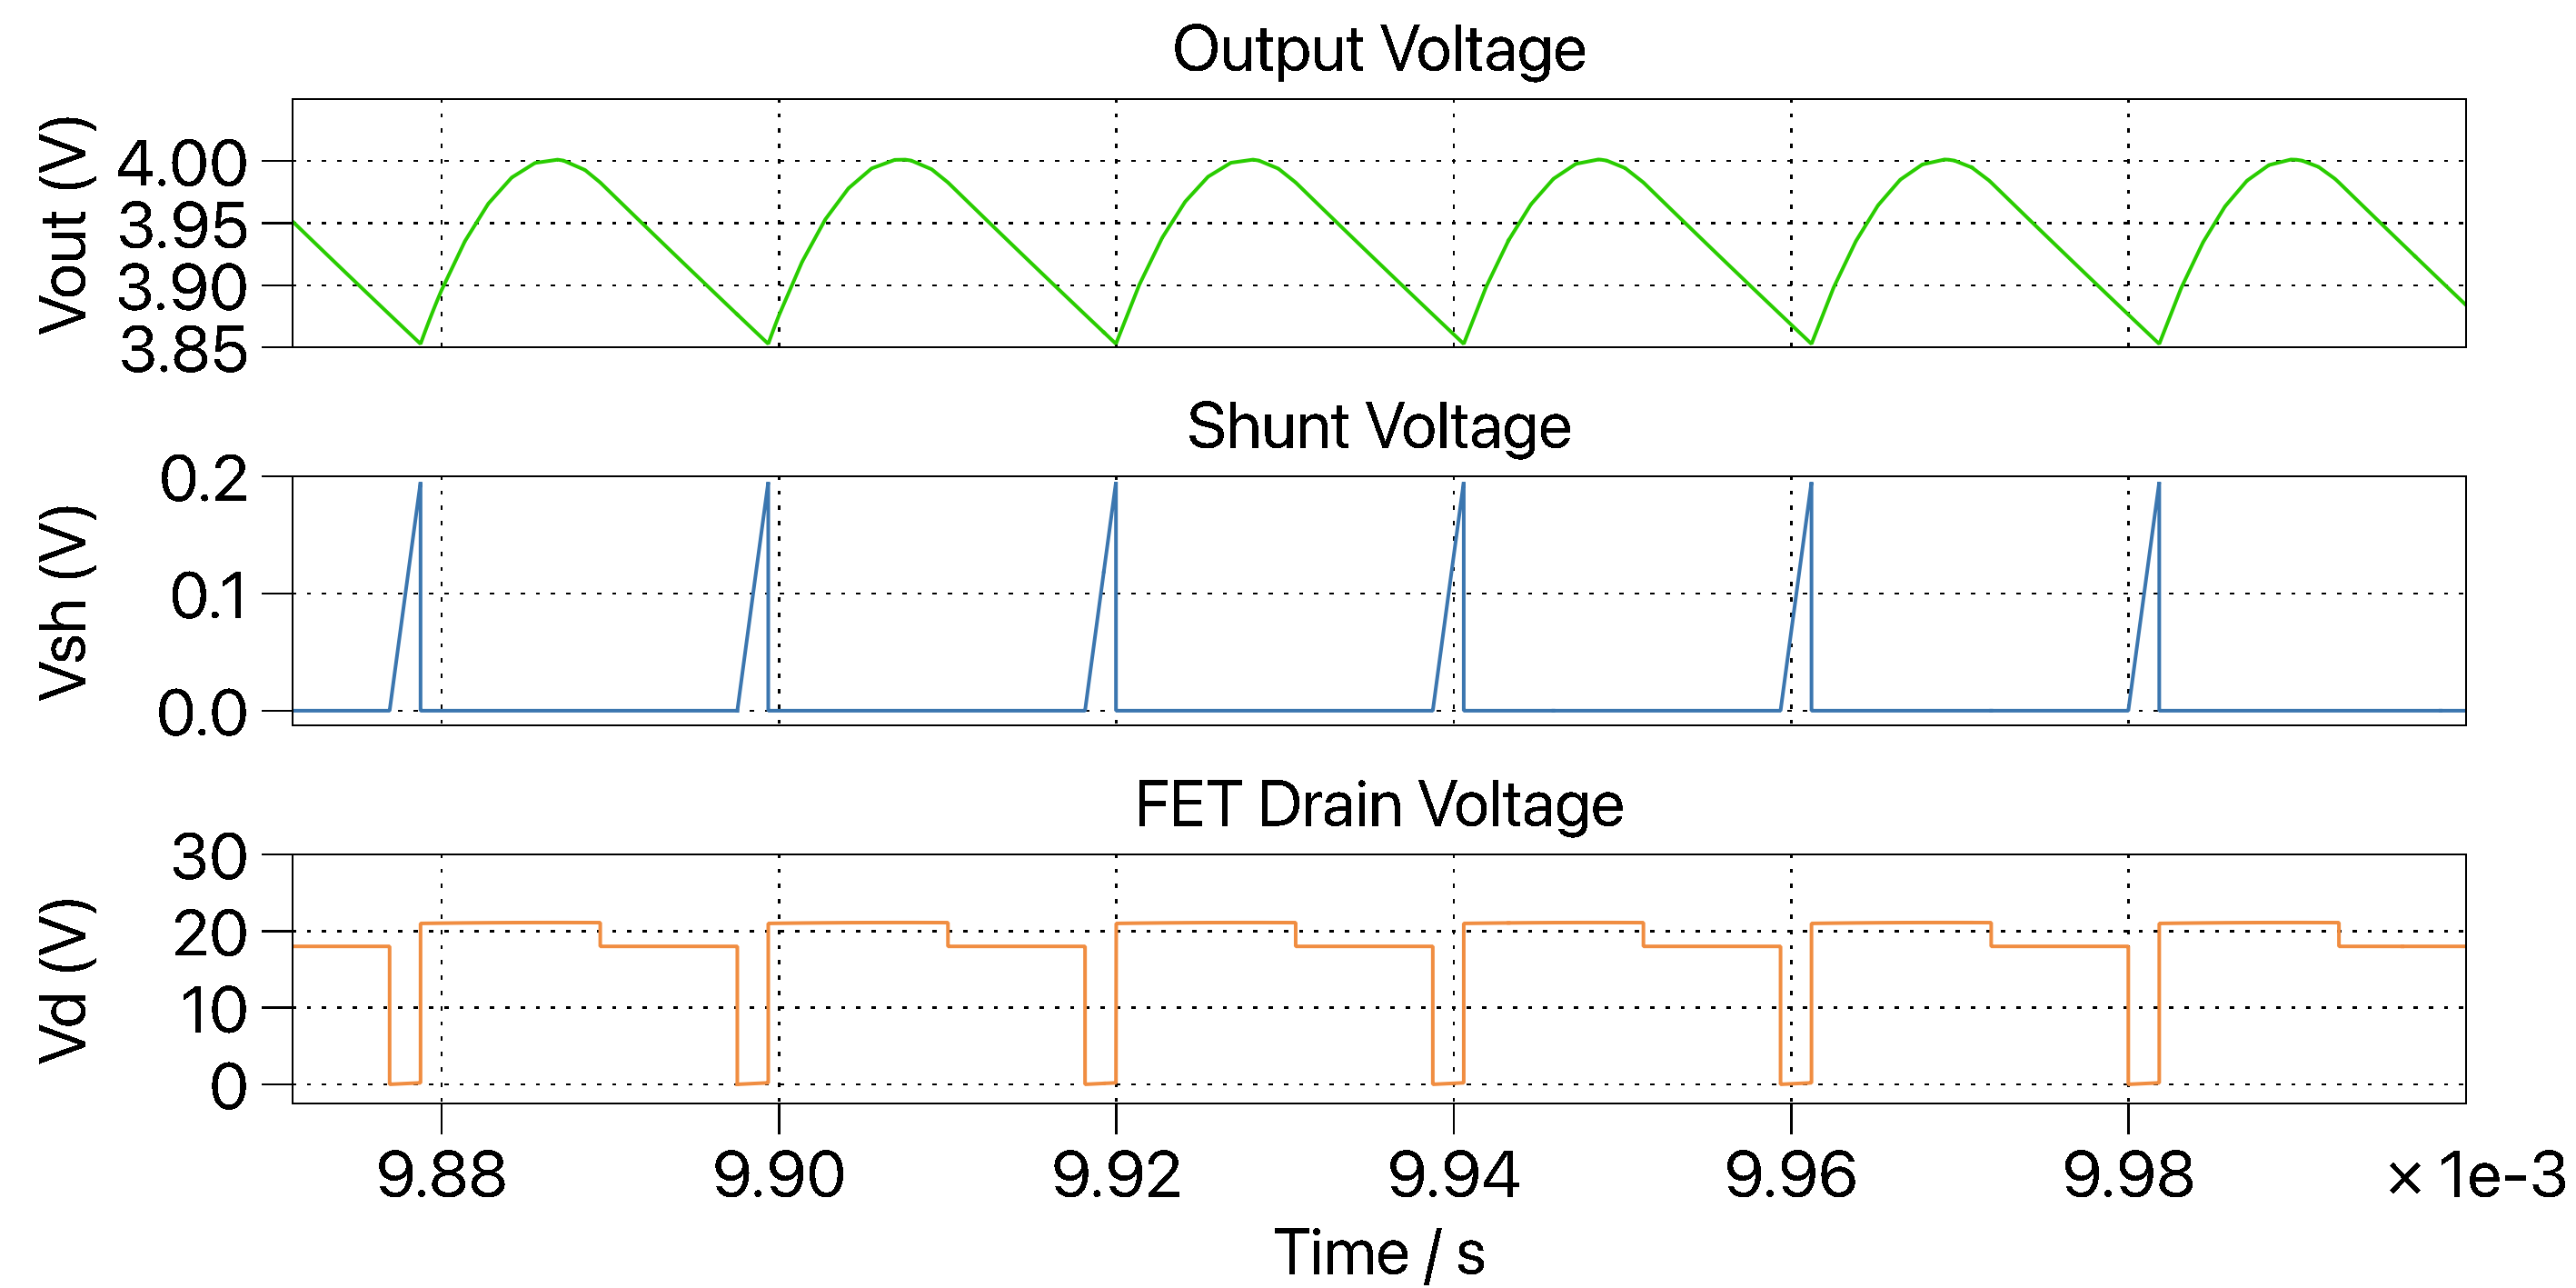

#### 6.990V Output
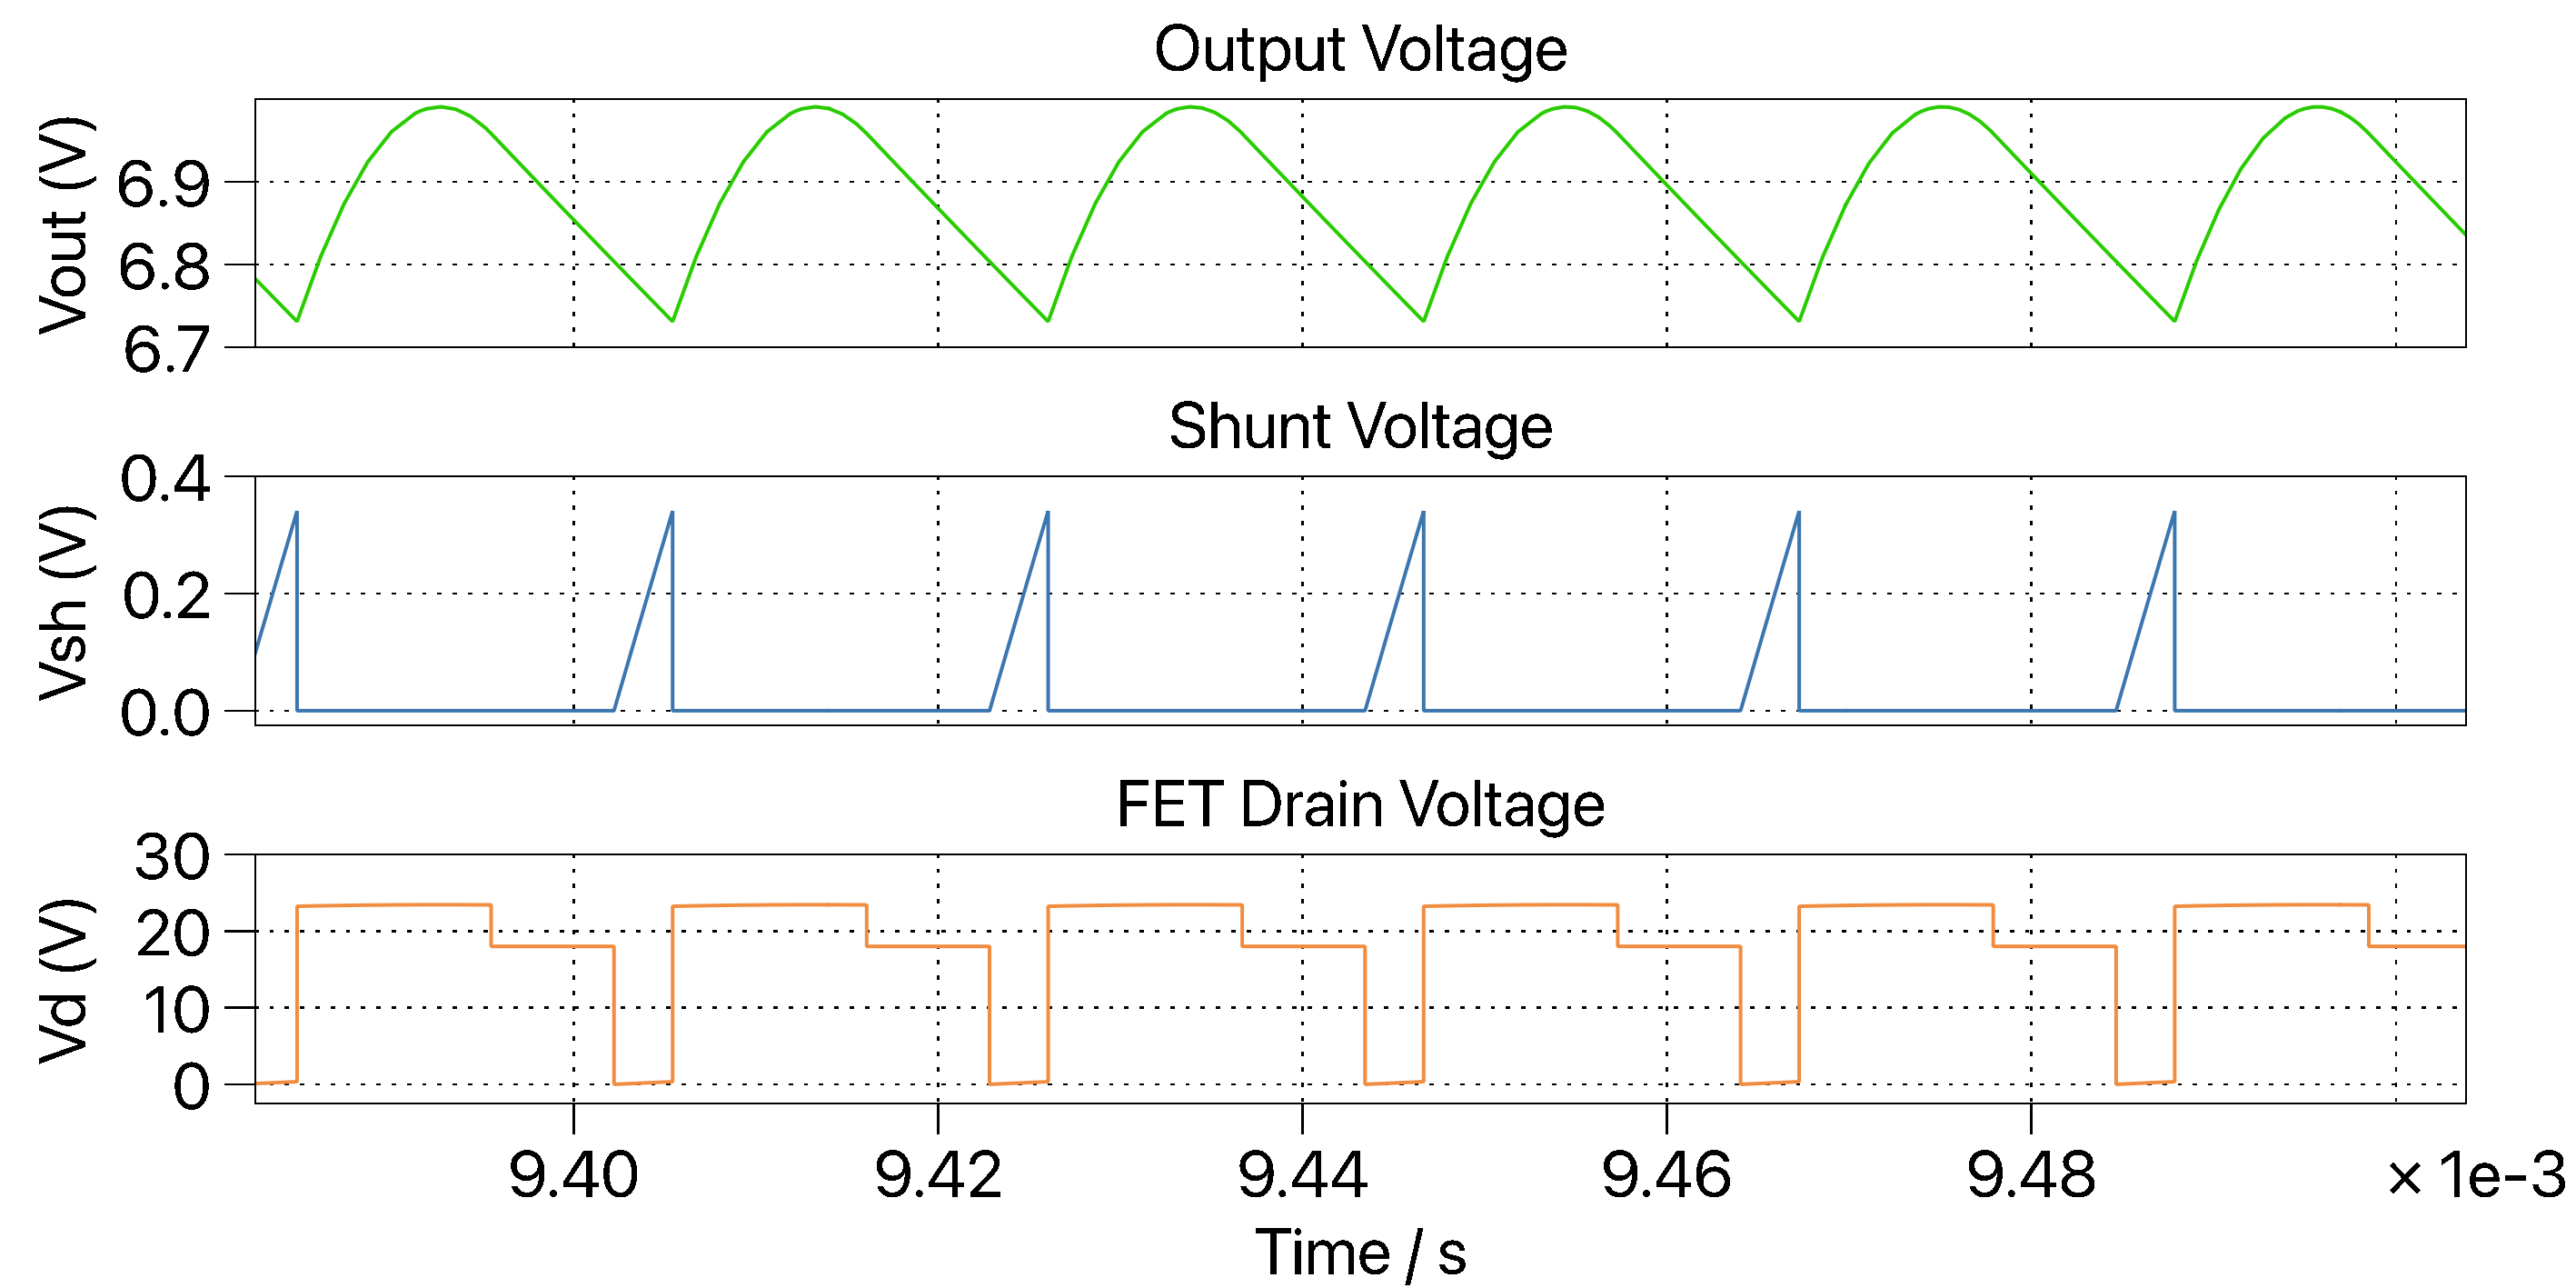

#### 9.000V Output
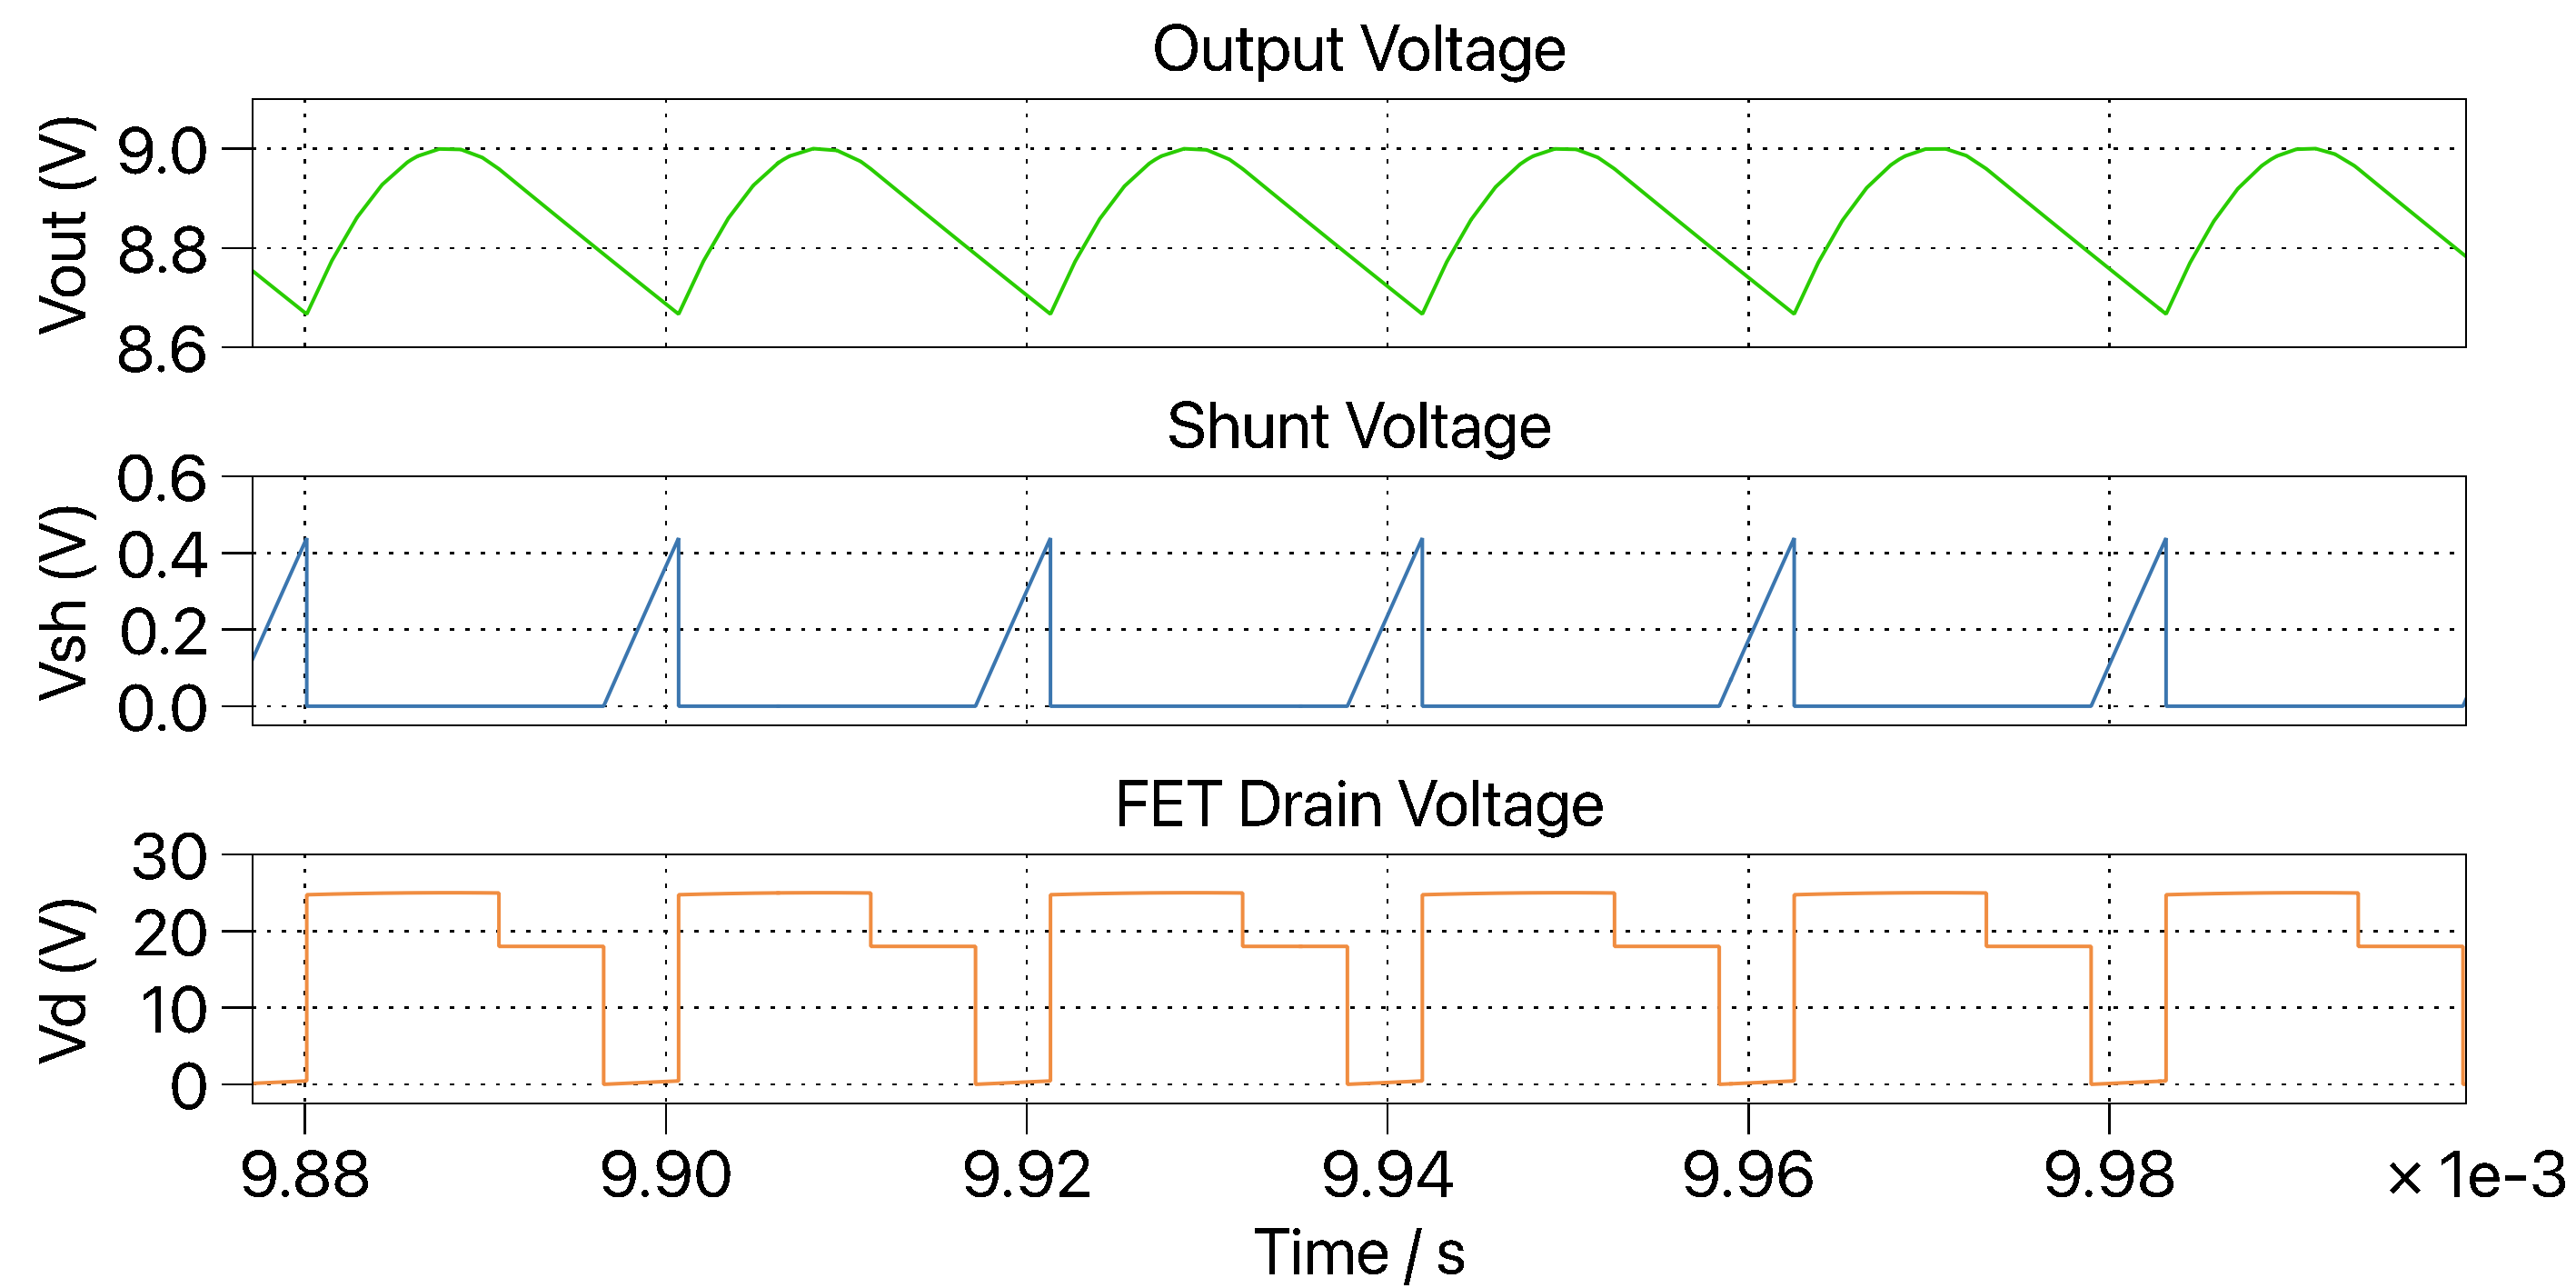

The waveforms of the shunt and drain voltages follow a similar shape to
the actual measured values, but the measured output has many more real-world
effects. The most evident of these are the ringing that occurs in the Vdrain
when the voltage switches to a different level, the two spikes in shunt voltage 
that happen when the MOSFET opens or closes, and the ringing visible in Vdrain 
when the MOSFET closes. For the Vdrain, there are three distinct modes in both
the measured and simulated plots -- the highest voltage when the MOSFET is open
but the secondary side diode is on, second highest when both the MOSFET is open
and the diode is off, and lowest when the MOSFET is closed/on. 

The output voltage measurement seems to be shifted up from the simulated values,
since the peak of the voltage is somewhat above 9.4V in the measurement but caps
off at exactly 9V in the simulation.

Both the measured and simulated plots switch at about 50kHz.

The simulated duty cycles are:

4V Output: 8.898%

7V Output: 15.61%

9V Output: 20.15%

These were each calculated using the cursor tool in PLECS on the Vgate signal.

#### Q10: Analyze the comparison and document your observations.
A. Are the simplifying assumptions made in our theoretical study of the flyback converter valid?

The simplification that all of our components are ideal and that there is no parasitic inductance or capacitance makes it so we don't
see any simulated ringing or undesired effects. The assumptions we made are therefore not helpful if we are trying to model failures in our circuit, but it is useful in determining things like output voltage, what an expected ripple might be, and helping us determine component values for that purpose.

B. Does the measured peak-current and duty-cycle match the theoretical predictions?

The peak current for the measured data can be calculated by taking the peak shunt voltage and dividing it by the shunt resistance. Thus, the following:

In [211]:
# The peak Vsh voltages were found by picking the peak point manually.
# 4.001V: 
print(f"4.001V measured peak output current: {0.215/0.05}A")
# 6.990V: 
print(f"6.990V measured peak output current: {0.407/0.05}A")
# 9.000V: 
print(f"9.000V measured peak output current: {0.521/0.05}A")

4.001V measured peak output current: 4.3A
6.990V measured peak output current: 8.139999999999999A
9.000V measured peak output current: 10.42A


The simulation peak currents are:
4.001V: 3.9006A

6.990V: 6.8146A

9.000V: 8.7741A

These values are relatively close to each other for the 4V output, but the measured and simulated output currents differ significantly for the 7V and 9V output voltage levels. 

The measured duty cycles are (measured by taking the proportion of the measured drain voltage at the lowest level and dividing it by the total period in the window):

4.001V: 10.15%

6.990V: 18.19%

9.000V: 24.68%

As compared to the simulation values (as written above as well) of:

4V Output: 8.898%

7V Output: 15.61%

9V Output: 20.15%

These simulated values were each calculated using the cursor tool in PLECS on the Vgate signal.

These are relatively close to each other as well.

C. Identify high frequency oscillations and theorize their possible causes.

There are high frequency oscillations at every switch of the MOSFET, probably caused by the resonance between the parasitic inductance and capacitance exchanging energy through fields and then not having anywhere to dissipate that energy. The addition of something like a snubber circuit would allow those oscillations be damped away, although it would also make it less efficient. In addition, although the data smoothing makes the oscillations less prominent for the Vdd and -Vinj measurements, there are two big oscillation events at the base of each ripple that is also not present in the simulations. These oscillations are likely also caused by switching, although I am not completely sure why. 

#### Q11: Determine the output capacitor value (sum of C20,C21,C22,C23) from the output voltage scope measurements at 4V, 7V and 9V. Comment on your results.
Allan pointed out to me that a fundamental relation between capacitance and voltage is I = C*dV/dt, which in our case can be applied to the output voltage and transformed to become $C_{out} = \frac{I_{out}}{\frac{dV_{out}}{dt}}$.

We can calculate the I_outs for each output voltage using the measured output voltage and dividing by Rsh. We can also calculate the change in voltage over time by extracting the slope from those regions.

In [214]:
I_out_4V = 4.003/R_SH
I_out_7V = 7.040/R_SH
I_out_9V = 9.060/R_SH

C_out4 = I_out_4V/vout_slope4
C_out7 = I_out_7V/vout_slope7
C_out9 = I_out_9V/vout_slope9

print(C_out4)
print(C_out7)
print(C_out9)

-0.0045293777068258
-0.0033062562892612816
-0.0028865853992710512
